In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
import matplotlib.patches as mpatches
import time

import collections
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

np.random.seed(0)


In [2]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


31 столбец Time, V1–V28 (PCA-компоненты), Amount, Class

In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

пропусков нет

In [ ]:
df.columns # смотрим столбцы в датасете

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Анализ дисбаланса классов

In [6]:
print('Обычные транзакции составляют', round(df['Class'].value_counts()[0]/len(df) * 100, 2), '% данных')
print('Мошеннические транзакции составляют', round(df['Class'].value_counts()[1]/len(df) * 100, 2), '% данных')

Обычные транзакции составляют 99.83 % данных
Мошеннические транзакции составляют 0.17 % данных


In [7]:
# value_counts()- словарь: ключ - уникальное значение класса, значение эт количество записей
print(df['Class'].value_counts())

# Обращение по ключу:
print(df['Class'].value_counts()[0])
print(df['Class'].value_counts()[1])


Class
0    284315
1       492
Name: count, dtype: int64
284315
492


284 315 обычных транзакций (класс 0) против 492 мошеннических (класс 1)

In [8]:
n_trans = round(df['Class'].value_counts()[0]/len(df) * 100, 2)
f_trans = round(df['Class'].value_counts()[1]/len(df) * 100, 2)

print(f'Обычные транзакции составляют  {n_trans} % данных')
print(f'Мошеннические транзакции составляют  {f_trans} % данных')

Обычные транзакции составляют  99.83 % данных
Мошеннические транзакции составляют  0.17 % данных


дисбаланс классов критически высокий

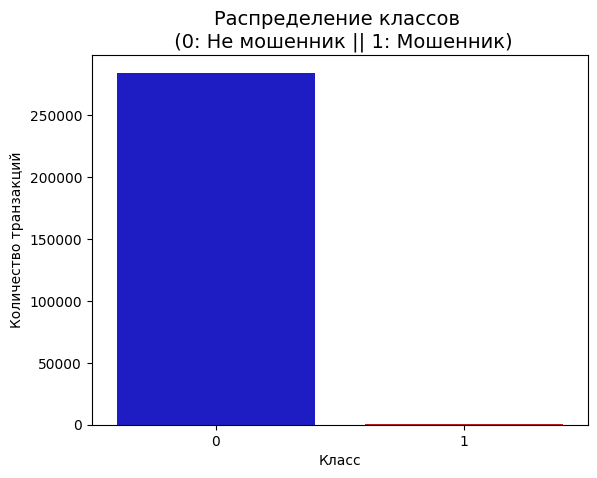

In [9]:
colors = ["#0101DF", "#DF0101"]

sns.countplot(x='Class', data=df, palette=colors)
plt.title('Распределение классов \n (0: Не мошенник || 1: Мошенник)', fontsize=14)
plt.xlabel('Класс')
plt.ylabel('Количество транзакций')
plt.show()

Распределения суммы и времени транзакций

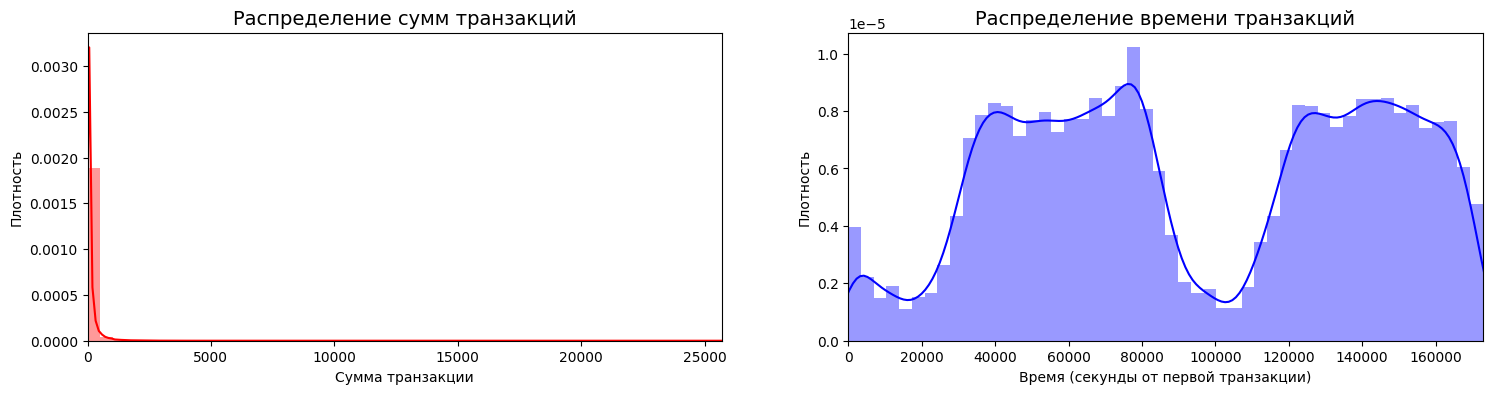

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(18, 4))

amount_val = df['Amount'].values
time_val   = df['Time'].values

sns.distplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Распределение сумм транзакций', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])
ax[0].set_xlabel('Сумма транзакции')
ax[0].set_ylabel('Плотность')

sns.distplot(time_val, ax=ax[1], color='b')
ax[1].set_title('Распределение времени транзакций', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])
ax[1].set_xlabel('Время (секунды от первой транзакции)')
ax[1].set_ylabel('Плотность')

plt.show()


Amount почти все транзакции мелкие, хвост до 25 000, сильная асимметрия. Time два горба= две ночи/два дня наблюдений. тоже нужно масштабировать

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()  # Менее чувствителен к выбросам, чем StandardScaler

X = df.drop('Class', axis=1)
y = df['Class']

original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Демонстрация типов данных перед масштабированием
rt_tmp = original_Xtrain['Amount']
print(f'Тип данных original_Xtrain["Amount"]                     {type(rt_tmp)}')
print(f'Тип данных original_Xtrain["Amount"].values              {type(rt_tmp.values)}')
print(f'Тип данных original_Xtrain["Amount"].values.reshape(-1,1) {type(rt_tmp.values.reshape(-1,1))}')
print()

# Масштабирование Amount
original_Xtrain['scaled_amount'] = rob_scaler.fit_transform(original_Xtrain['Amount'].values.reshape(-1, 1))
original_Xtest['scaled_amount']  = rob_scaler.fit_transform(original_Xtest['Amount'].values.reshape(-1, 1))

# Масштабирование Time
original_Xtrain['scaled_time'] = rob_scaler.fit_transform(original_Xtrain['Time'].values.reshape(-1, 1))
original_Xtest['scaled_time']  = rob_scaler.fit_transform(original_Xtest['Time'].values.reshape(-1, 1))

# Удаляем исходные немасштабированные столбцы
original_Xtrain.drop(['Time', 'Amount'], axis=1, inplace=True)
original_Xtest.drop(['Time', 'Amount'], axis=1, inplace=True)

# Конвертируем в numpy arrays
original_Xtrain = original_Xtrain.values
original_Xtest  = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest  = original_ytest.values

train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label,  test_counts_label  = np.unique(original_ytest,  return_counts=True)

print('Распределение классов:\n')
print("Обучающий набор:", train_counts_label / len(original_ytrain))
print("Тестовый набор: ", test_counts_label  / len(original_ytest))


Тип данных original_Xtrain["Amount"]                     <class 'pandas.core.series.Series'>
Тип данных original_Xtrain["Amount"].values              <class 'numpy.ndarray'>
Тип данных original_Xtrain["Amount"].values.reshape(-1,1) <class 'numpy.ndarray'>

Распределение классов:

Обучающий набор: [0.99827075 0.00172925]
Тестовый набор:  [0.99827955 0.00172045]


Оба набора имеют идентичное соотношение классов

Random Under-Sampling формирование сбалансированной подвыборки

In [12]:
# Перемешиваем датасет
df = df.sample(frac=1)

fraud_df     = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492]  # берём 492 немошеннических транзакции

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Финальное перемешивание
new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
178066,123462.0,-2.929579,-2.630494,1.775473,-2.310854,-0.490392,-0.042834,-1.674939,0.399247,-0.567327,...,-0.280585,-0.294464,-0.455937,0.479731,0.443785,-0.255994,-1.050257,0.587969,19.95,0
181966,125200.0,-0.769172,1.342212,-2.171454,-0.151513,-0.648374,-0.973504,-1.706658,0.313745,-1.982302,...,-0.036122,-0.753591,-0.047113,0.358493,-0.287407,0.476506,0.250531,0.250987,40.00,1
265205,161783.0,-0.161936,0.474341,-0.758422,-0.953533,0.751166,-1.570174,2.117030,-0.600490,0.069598,...,0.245031,0.766910,0.028772,-0.039268,-0.383179,0.067253,0.177143,0.049525,118.85,0
144754,86376.0,-0.670238,0.945206,0.610051,2.640065,-2.707775,1.952611,-1.624608,-5.229908,0.210202,...,-2.504450,1.436472,0.351542,0.648467,0.579681,0.075738,0.346717,0.282209,323.77,1
238222,149582.0,-4.280584,1.421100,-3.908229,2.942946,-0.076205,-2.002526,-2.874155,-0.856005,0.963674,...,-0.140062,-0.907720,-0.680108,-0.349170,0.056276,-1.149923,-1.809886,0.723051,1.10,1


 создана подвыборка с равным числом мошеннических и нормальных транзакций

In [13]:
print('Размер подвыборки:', new_df.shape)

Размер подвыборки: (984, 31)


Распределение классов в подвыборке
Class
0    0.5
1    0.5
Name: count, dtype: float64


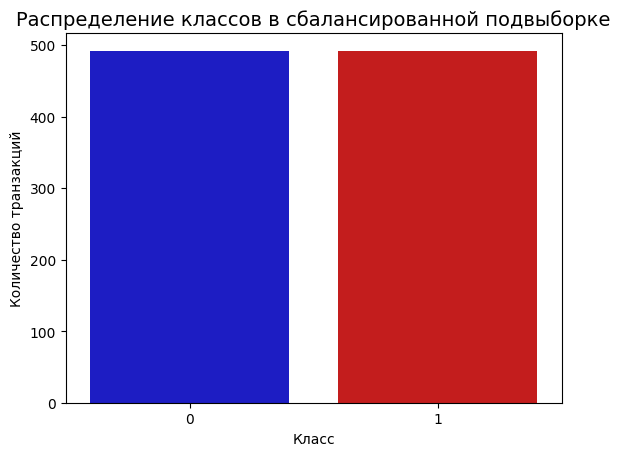

In [14]:
print('Распределение классов в подвыборке')
print(new_df['Class'].value_counts() / len(new_df))

sns.countplot(x='Class', data=new_df, palette=colors)
plt.title('Распределение классов в сбалансированной подвыборке', fontsize=14)
plt.xlabel('Класс')
plt.ylabel('Количество транзакций')
plt.show()


соотношение классов 50/50

Строим матрицу корреляций именно на сбалансированной подвыборке, иначе дисбаланс классов исказит картину

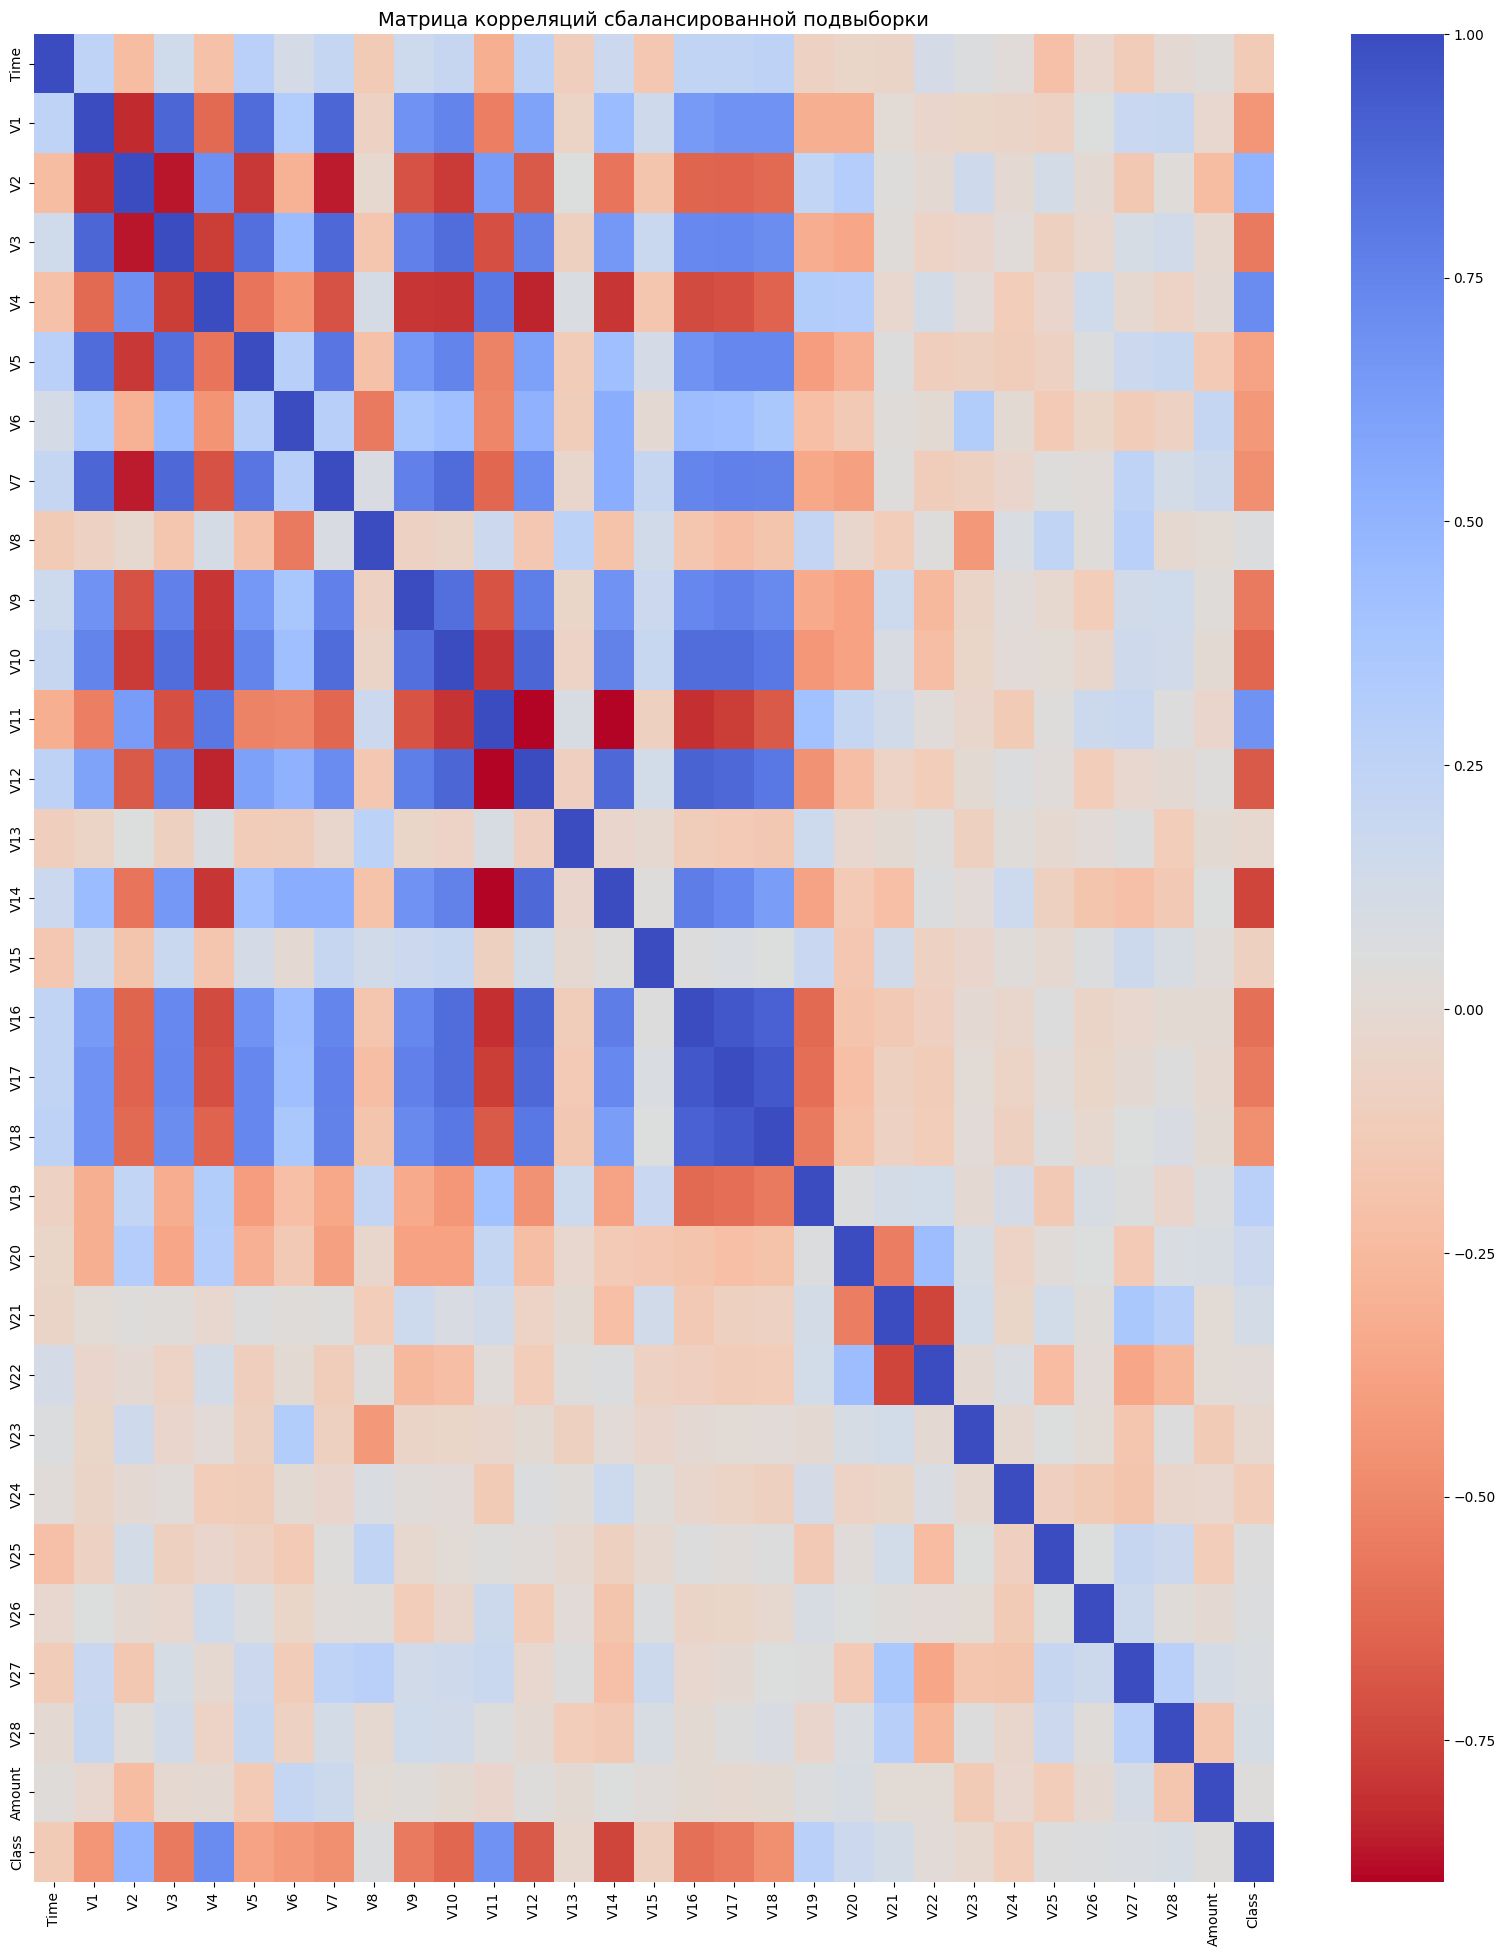

In [15]:
f, ax = plt.subplots(1, 1, figsize=(20, 24))

sub_sample_corr = new_df.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size': 20}, ax=ax)
ax.set_title('Матрица корреляций сбалансированной подвыборки', fontsize=14)
plt.show()


Отрицательная корреляция с Class (красные): V17, V14, V12, V10 низкие значения - признак мошенничества. Положительная корреляция с Class (синие): V4, V11, V2, V19 — высокие значения = признак мошенничества. Time и Amount практически не коррелируют с Class

 признаки с отрицательной корреляцией

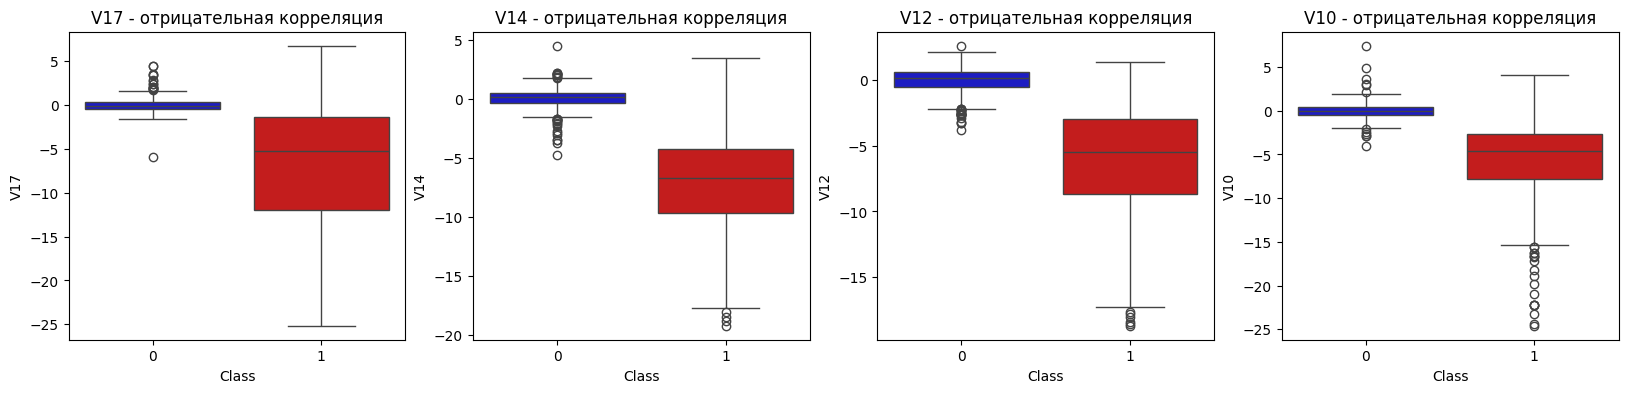

In [16]:
f, axes = plt.subplots(ncols=4, figsize=(20, 4))

sns.boxplot(x='Class', y='V17', data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('V17 - отрицательная корреляция', fontsize=12)

sns.boxplot(x='Class', y='V14', data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('V14 - отрицательная корреляция', fontsize=12)

sns.boxplot(x='Class', y='V12', data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('V12 - отрицательная корреляция', fontsize=12)

sns.boxplot(x='Class', y='V10', data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('V10 - отрицательная корреляция', fontsize=12)

plt.show()


Классы чётко разделены. у мошенников (класс 1) значения V17, V14, V12, V10 стабильно уходят в минус, у нормальных (класс 0) около нуля. Видны выбросы, особенно в V10 до −25 

признаки с положительной корреляцией

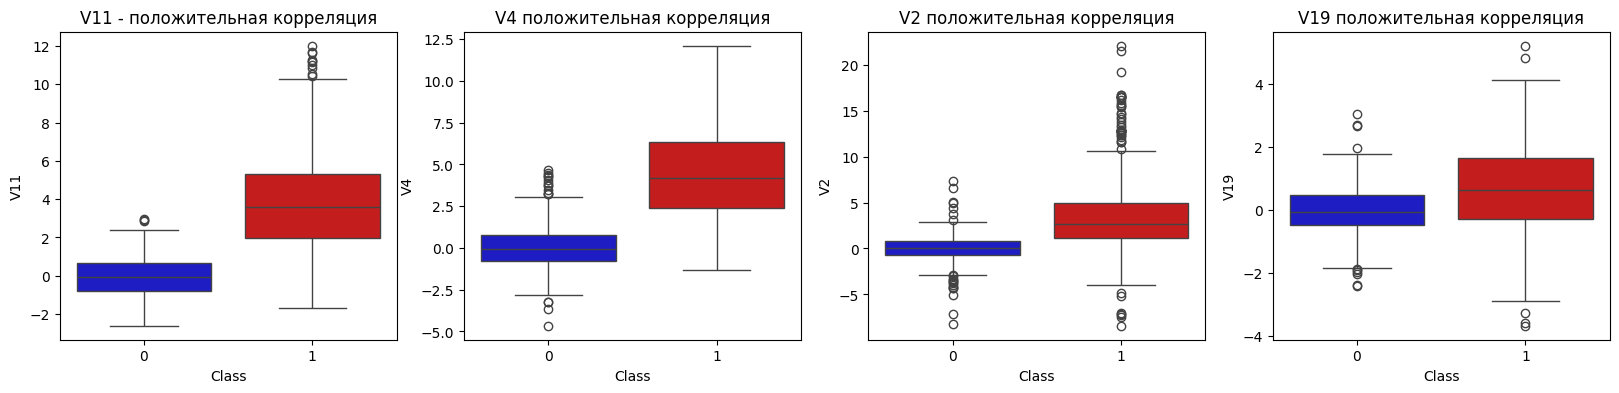

In [17]:
f, axes = plt.subplots(ncols=4, figsize=(20, 4))

sns.boxplot(x='Class', y='V11', data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('V11 - положительная корреляция', fontsize=12)

sns.boxplot(x='Class', y='V4', data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('V4 положительная корреляция', fontsize=12)

sns.boxplot(x='Class', y='V2', data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('V2 положительная корреляция', fontsize=12)

sns.boxplot(x='Class', y='V19', data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('V19 положительная корреляция', fontsize=12)

plt.show()


Зеркальная картина предыдущего шага у мошенников (класс 1) значения V11, V4, V2, V19 заметно выше, чем у нормальных (класс 0). Разделение классов хорошее, особенно по V11 и V4. Выбросы присутствуют, но менее экстремальные

Обработка выбросов метод IQR

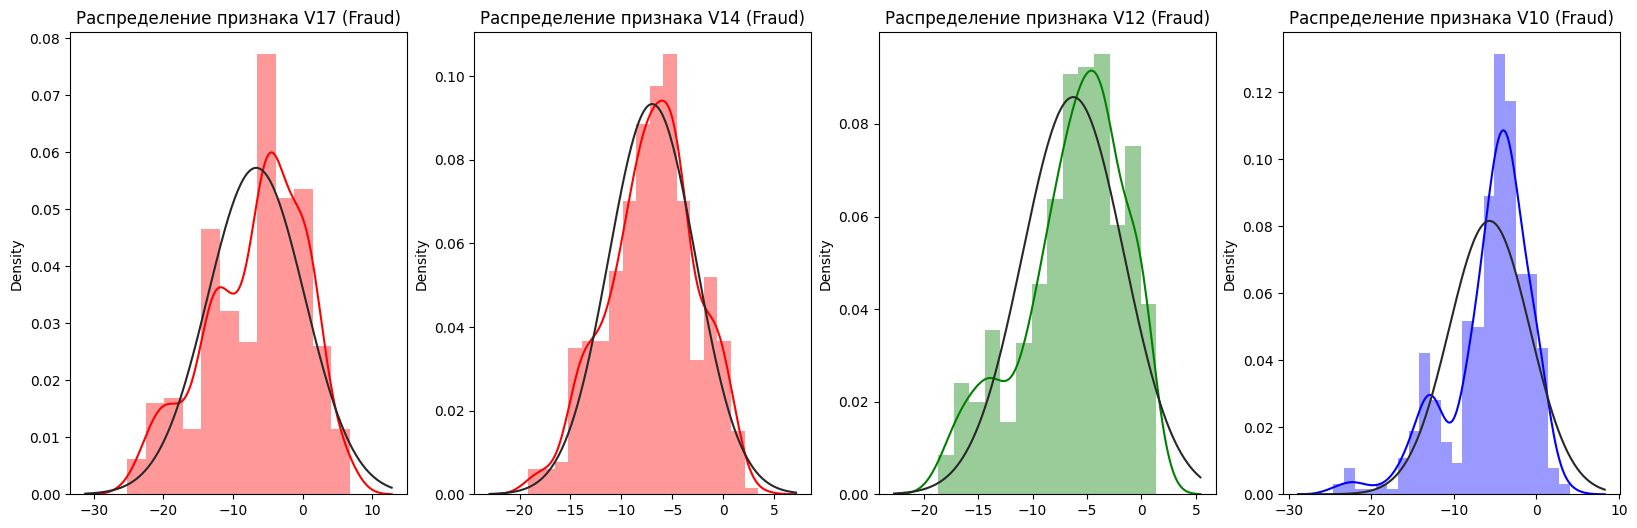

In [18]:
from scipy.stats import norm

f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 6))

v17_fraud_dist = new_df['V17'].loc[new_df['Class'] == 1].values
sns.distplot(v17_fraud_dist, ax=ax1, fit=norm, color='r')
ax1.set_title('Распределение признака V17 (Fraud)', fontsize=12)

v14_fraud_dist = new_df['V14'].loc[new_df['Class'] == 1].values
sns.distplot(v14_fraud_dist, ax=ax2, fit=norm, color='r')
ax2.set_title('Распределение признака V14 (Fraud)', fontsize=12)

v12_fraud_dist = new_df['V12'].loc[new_df['Class'] == 1].values
sns.distplot(v12_fraud_dist, ax=ax3, fit=norm, color='g')
ax3.set_title('Распределение признака V12 (Fraud)', fontsize=12)

v10_fraud_dist = new_df['V10'].loc[new_df['Class'] == 1].values
sns.distplot(v10_fraud_dist, ax=ax4, fit=norm, color='b')
ax4.set_title('Распределение признака V10 (Fraud)', fontsize=12)

plt.show()


Все четыре признака у мошенников сосредоточены в отрицательной зоне (−10…0),подтверждает отрицательную корреляцию с Class

Вычисление границ IQR и удаление выбросов

In [19]:
# V17 
v17_fraud = new_df['V17'].loc[new_df['Class'] == 1].values
q25, q75  = np.percentile(v17_fraud, 25), np.percentile(v17_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
v17_iqr   = q75 - q25
print('iqr: {}'.format(v17_iqr))
v17_cut_off           = v17_iqr * 1.5
v17_lower, v17_upper  = q25 - v17_cut_off, q75 + v17_cut_off
print('Порог: {}'.format(v17_cut_off))
print('V17 нижняя граница: {}'.format(v17_lower))
print('V17 верхняя граница: {}'.format(v17_upper))
outliers = [x for x in v17_fraud if x < v17_lower or x > v17_upper]
print('Количество выбросов: {}'.format(len(outliers)))
new_df_without_outliers = new_df.drop(
    new_df[(new_df['V17'] > v17_upper) | (new_df['V17'] < v17_lower)].index
)
print('----' * 44)

# V14 
v14_fraud = new_df['V14'].loc[new_df['Class'] == 1].values
q25, q75  = np.percentile(v14_fraud, 25), np.percentile(v14_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
v14_iqr   = q75 - q25
print('iqr: {}'.format(v14_iqr))
v14_cut_off           = v14_iqr * 1.5
v14_lower, v14_upper  = q25 - v14_cut_off, q75 + v14_cut_off
print('Порог: {}'.format(v14_cut_off))
print('V14 нижняя граница: {}'.format(v14_lower))
print('V14 верхняя граница: {}'.format(v14_upper))
outliers = [x for x in v14_fraud if x < v14_lower or x > v14_upper]
print('Количество выбросов: {}'.format(len(outliers)))
new_df_without_outliers = new_df_without_outliers.drop(
    new_df_without_outliers[
        (new_df_without_outliers['V14'] > v14_upper) |
        (new_df_without_outliers['V14'] < v14_lower)
    ].index
)
print('----' * 44)

#  V12
v12_fraud = new_df['V12'].loc[new_df['Class'] == 1].values
q25, q75  = np.percentile(v12_fraud, 25), np.percentile(v12_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
v12_iqr   = q75 - q25
print('iqr: {}'.format(v12_iqr))
v12_cut_off           = v12_iqr * 1.5
v12_lower, v12_upper  = q25 - v12_cut_off, q75 + v12_cut_off
print('Порог: {}'.format(v12_cut_off))
print('V12 нижняя граница: {}'.format(v12_lower))
print('V12 верхняя граница: {}'.format(v12_upper))
outliers = [x for x in v12_fraud if x < v12_lower or x > v12_upper]
print('Количество выбросов: {}'.format(len(outliers)))
new_df_without_outliers = new_df_without_outliers.drop(
    new_df_without_outliers[
        (new_df_without_outliers['V12'] > v12_upper) |
        (new_df_without_outliers['V12'] < v12_lower)
    ].index
)
print('----' * 44)

#  V10 
v10_fraud = new_df['V10'].loc[new_df['Class'] == 1].values
q25, q75  = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
v10_iqr   = q75 - q25
print('iqr: {}'.format(v10_iqr))
v10_cut_off           = v10_iqr * 1.5
v10_lower, v10_upper  = q25 - v10_cut_off, q75 + v10_cut_off
print('Порог: {}'.format(v10_cut_off))
print('V10 нижняя граница: {}'.format(v10_lower))
print('V10 верхняя граница: {}'.format(v10_upper))
outliers = [x for x in v10_fraud if x < v10_lower or x > v10_upper]
print('Количество выбросов: {}'.format(len(outliers)))
new_df_without_outliers = new_df_without_outliers.drop(
    new_df_without_outliers[
        (new_df_without_outliers['V10'] > v10_upper) |
        (new_df_without_outliers['V10'] < v10_lower)
    ].index
)


Квартиль 25: -11.945057187644576 | Квартиль 75: -1.34193993162032
iqr: 10.603117256024255
Порог: 15.904675884036383
V17 нижняя граница: -27.84973307168096
V17 верхняя граница: 14.562735952416062
Количество выбросов: 0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Квартиль 25: -9.692722964972386 | Квартиль 75: -4.282820849486865
iqr: 5.409902115485521
Порог: 8.114853173228282
V14 нижняя граница: -17.807576138200666
V14 верхняя граница: 3.8320323237414167
Количество выбросов: 4
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Квартиль 25: -8.688176521812306 | Квартиль 75: -2.97408802538493
iqr: 5.714088496427376
Порог: 8.571132744641064
V12 нижняя граница: -17.25930926645337
V12 верхняя граница: 5.597044719256134
Количество выбросов:

V17выбросов нет, распределение достаточно компактное. V10 наибольшее количество выбросов (19). 

до и после удаления выбросов

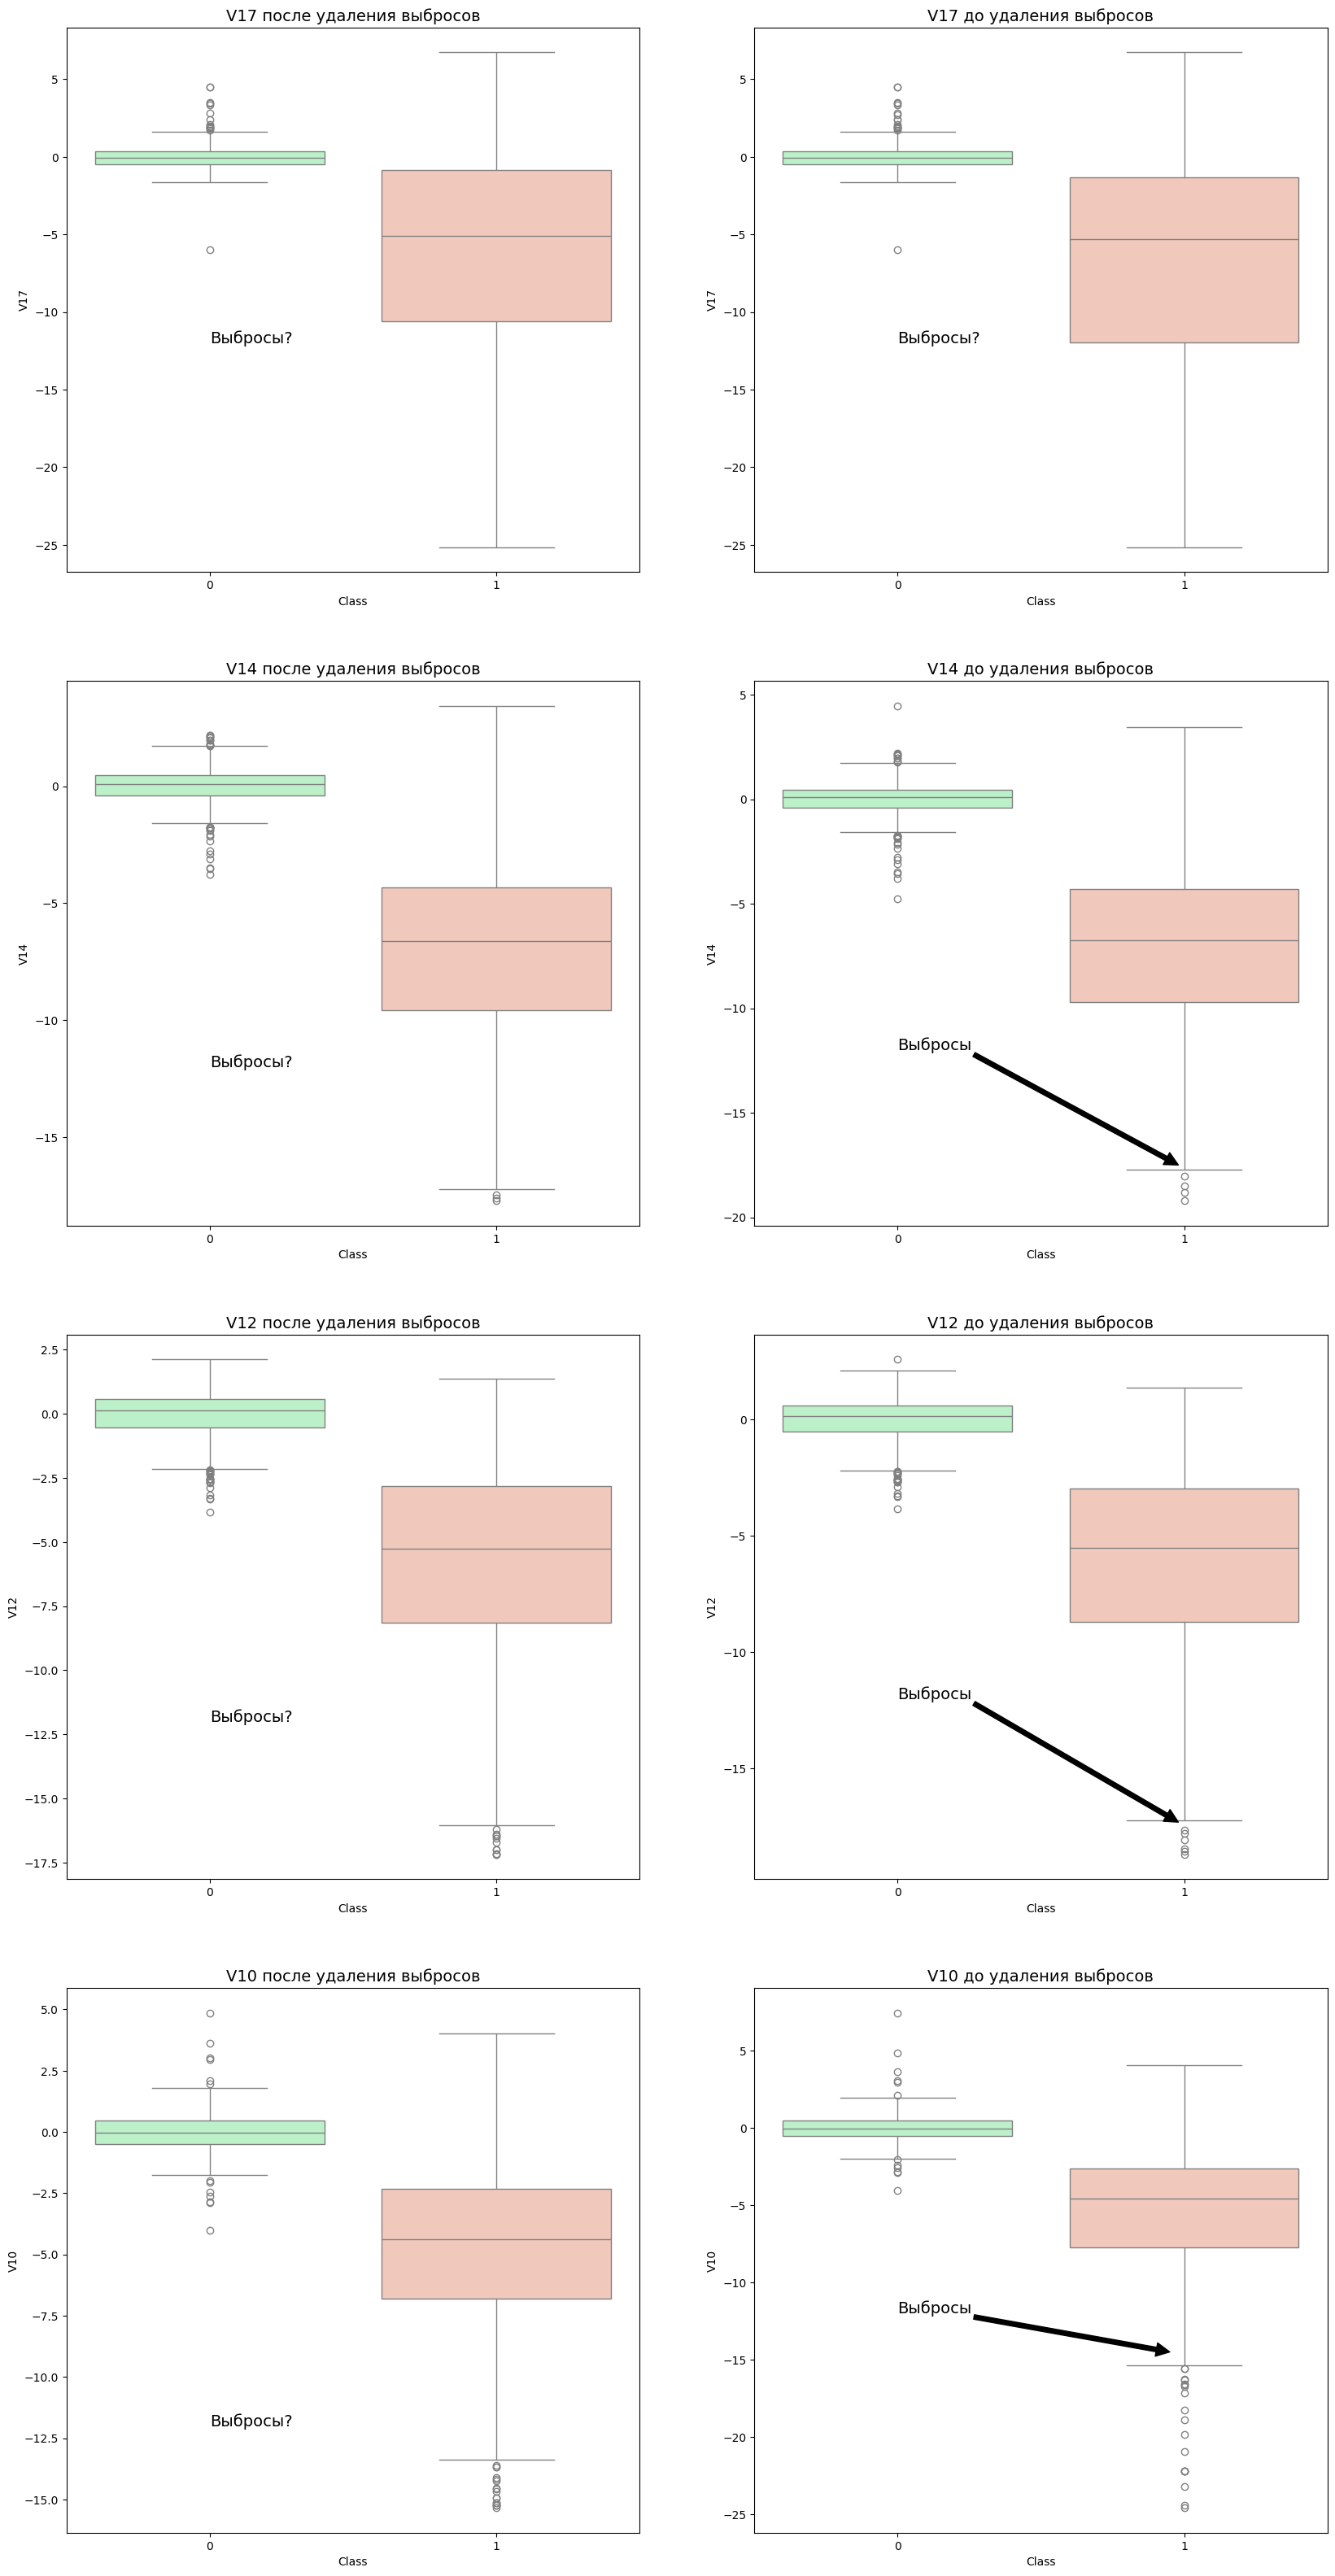

In [21]:
f, ax = plt.subplots(4, 2, figsize=(20, 40))
colors_box = ['#B3F9C5', '#f9c5b3']

# V17
sns.boxplot(x="Class", y="V17", data=new_df_without_outliers, ax=ax[0, 0], palette=colors_box)
ax[0, 0].set_title("V17 после удаления выбросов", fontsize=14)
ax[0, 0].annotate('Выбросы?', xy=(0.9, 0.1), xytext=(0, -12), fontsize=14)

sns.boxplot(x="Class", y="V17", data=new_df, ax=ax[0, 1], palette=colors_box)
ax[0, 1].set_title("V17 до удаления выбросов", fontsize=14)
ax[0, 1].annotate('Выбросы?', xy=(0.98, -17.5), xytext=(0, -12), fontsize=14)

# V14
sns.boxplot(x="Class", y="V14", data=new_df_without_outliers, ax=ax[1, 0], palette=colors_box)
ax[1, 0].set_title("V14 после удаления выбросов", fontsize=14)
ax[1, 0].annotate('Выбросы?', xy=(0.9, 0.1), xytext=(0, -12), fontsize=14)

sns.boxplot(x="Class", y="V14", data=new_df, ax=ax[1, 1], palette=colors_box)
ax[1, 1].set_title("V14 до удаления выбросов", fontsize=14)
ax[1, 1].annotate('Выбросы', xy=(0.98, -17.5), xytext=(0, -12),
                  arrowprops=dict(facecolor='black'), fontsize=14)

# V12
sns.boxplot(x="Class", y="V12", data=new_df_without_outliers, ax=ax[2, 0], palette=colors_box)
ax[2, 0].set_title("V12 после удаления выбросов", fontsize=14)
ax[2, 0].annotate('Выбросы?', xy=(0.9, 0.1), xytext=(0, -12), fontsize=14)

sns.boxplot(x="Class", y="V12", data=new_df, ax=ax[2, 1], palette=colors_box)
ax[2, 1].set_title("V12 до удаления выбросов", fontsize=14)
ax[2, 1].annotate('Выбросы', xy=(0.98, -17.3), xytext=(0, -12),
                  arrowprops=dict(facecolor='black'), fontsize=14)

# V10
sns.boxplot(x="Class", y="V10", data=new_df_without_outliers, ax=ax[3, 0], palette=colors_box)
ax[3, 0].set_title("V10 после удаления выбросов", fontsize=14)
ax[3, 0].annotate('Выбросы?', xy=(0.9, 0.1), xytext=(0, -12), fontsize=14)

sns.boxplot(x="Class", y="V10", data=new_df, ax=ax[3, 1], palette=colors_box)
ax[3, 1].set_title("V10 до удаления выбросов", fontsize=14)
ax[3, 1].annotate('Выбросы', xy=(0.95, -14.5), xytext=(0, -12),
                  arrowprops=dict(facecolor='black'), fontsize=14)

plt.show()


Выбросы успешно удалены. У V14, V12, V10 усы заметно укоротились

In [22]:
# Обновляем рабочий датафрейм
new_df = new_df_without_outliers
print('Итоговый размер датафрейма после удаления выбросов:', new_df.shape)


Итоговый размер датафрейма после удаления выбросов: (955, 31)


Понижение размерности и кластеризация

In [23]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

X = new_df.drop('Class', axis=1)
y = new_df['Class']

# Time и Amount почти не коррелируют с таргетом (убираем)
if 'Time' in X.columns and 'Amount' in X.columns:
    X.drop(['Time', 'Amount'], axis=1, inplace=True)

#t-SNE
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("T-SNE заняло {:.2f} сек".format(t1 - t0))

#  PCA
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("PCA заняло {:.2f} сек".format(t1 - t0))

# Truncated SVD
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD заняло {:.2f} сек".format(t1 - t0))


T-SNE заняло 4.47 сек
PCA заняло 0.01 сек
Truncated SVD заняло 0.00 сек
